# Predictive Maintenance for Robotics Manufacturing

## Business Problem

Kataoka aims to reduce unplanned robotic failures by predicting equipment degradation before breakdown occurs.

Unexpected failures lead to:
- production downtime
- financial losses
- reduced client trust

## Objective

This project explores whether sensor data can be used to predict Remaining Useful Life (RUL) and detect early signs of failure.

## EDA Goal

To understand:
- data quality and structure
- failure patterns
- sensor behaviour
- whether a predictive signal exists before failure

This notebook is written for both technical and non-technical stakeholders.


## Import Libraries

In [308]:
# Import the main libraries needed for data analysis.
# pandas helps us work with tables.
# numpy supports numerical calculations.
# matplotlib and seaborn help us create charts for visual analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean chart style for easier readability.
sns.set(style="whitegrid")

## Load the Dataset in Pandas DataFrame

In [309]:
# Load all raw datasets from the data/raw folder into pandas DataFrames.
# These four files represent the core project data sources.
# Some of these files have timestamp columns that we parse as dates for easier time-based analysis later on.

robot_df = pd.read_csv("../data/raw/robot_units.csv")
sensor_df = pd.read_csv("../data/raw/sensor_readings.csv")
maintenance_df = pd.read_csv("../data/raw/maintenance_logs.csv")
failure_df = pd.read_csv("../data/raw/failure_events.csv")   

print("All datasets loaded successfully.")


All datasets loaded successfully.


### Stakeholder Interpretation

We have loaded four business data sources:

- robot_units: robot profile information
- sensor_readings: time-series sensor behaviour
- maintenance_logs: historical maintenance activity
- failure_events: recorded robot failures

These tables will later be combined carefully to create a modelling dataset.

## Inspect Dataset Size

In [337]:
# Store all datasets in a dictionary so we can inspect them consistently in a loop.
datasets = {
    "robot_df": robot_df,
    "sensor_df": sensor_df,
    "maintenance_df": maintenance_df,
    "failure_df": failure_df
}

# Loop through each dataset and print out the number of rows and columns.
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

robot_df: 50 rows, 5 columns
sensor_df: 76730 rows, 7 columns
maintenance_df: 262 rows, 5 columns
failure_df: 17 rows, 5 columns


### Stakeholder Interpretation

The dataset contains 50 robots and 76,730 sensor readings.

However, only 17 failure events are recorded. This means the RUL model will have limited confirmed failure examples to learn from.

This is an important project risk and will influence how we split the data and evaluate model performance.

## Preview the tables

In [311]:
# Display the first five rows of each dataset.
# This helps us understand what each table contains before making any transformations.

for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


robot_units


,robot_id,model_type,installation_date,factory_location,operating_environment
0,ROB-0001,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
1,ROB-0002,ARM-X9,2023-02-05,Osaka Plant,"Clean Room (20-22°C, 40% RH)"
2,ROB-0003,ASSEMBLY-A3,2023-04-19,Osaka Plant,"Clean Room (20-22°C, 40% RH)"
3,ROB-0004,ARM-X7,2023-02-25,Tokyo Factory,"Clean Room (20-22°C, 40% RH)"
4,ROB-0005,ASSEMBLY-A3,2023-02-20,Hokkaido Lab,"Climate Controlled (22-25°C, 50% RH)"



sensor_readings


,reading_id,robot_id,timestamp,vibration_level,motor_temperature,torque_load,power_consumption
0,READ-000001,ROB-0001,2023-01-07 00:00:00,0.288,70.1,136.1,1471.0
1,READ-000002,ROB-0001,2023-01-07 06:00:00,0.135,70.2,139.5,811.1
2,READ-000003,ROB-0001,2023-01-07 12:00:00,0.277,47.9,123.5,752.5
3,READ-000004,ROB-0001,2023-01-07 18:00:00,0.172,58.2,111.2,610.9
4,READ-000005,ROB-0001,2023-01-08 00:00:00,0.465,52.8,68.2,1234.0



maintenance_logs


,maintenance_id,robot_id,maintenance_type,issue_detected,downtime_hours
0,MAINT-000001,ROB-0001,calibration,Minor wear detected,0.7
1,MAINT-000002,ROB-0001,lubrication,No issue found - routine check,3.1
2,MAINT-000003,ROB-0001,inspection,Minor wear detected,2.2
3,MAINT-000004,ROB-0001,lubrication,Minor wear detected,3.9
4,MAINT-000005,ROB-0001,inspection,No issue found - routine check,0.7



failure_events


,failure_id,robot_id,failure_type,failure_time,root_cause
0,FAIL-0001,ROB-0018,bearing_failure,2024-04-06,electrical surge
1,FAIL-0002,ROB-0043,motor_failure,2023-09-10,lubrication breakdown
2,FAIL-0003,ROB-0032,overheating,2024-04-15,overload operation
3,FAIL-0004,ROB-0014,joint_wear,2023-06-06,thermal cycling fatigue
4,FAIL-0005,ROB-0035,encoder_drift,2023-08-21,electrical surge


## Check columns and data types

In [312]:
# Check column names, data types, and non-null counts.
# This is important because timestamp columns must be converted before time-based analysis.
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.info())


robot_units
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   robot_id               50 non-null     object
 1   model_type             50 non-null     object
 2   installation_date      50 non-null     object
 3   factory_location       50 non-null     object
 4   operating_environment  50 non-null     object
dtypes: object(5)
memory usage: 2.1+ KB


None


sensor_readings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76730 entries, 0 to 76729
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reading_id         76730 non-null  object 
 1   robot_id           76730 non-null  object 
 2   timestamp          76730 non-null  object 
 3   vibration_level    76730 non-null  float64
 4   motor_temperature  76730 non-null  float64
 5   torque_load        76730 non-null  float64
 6   power_consumption  76730 non-null  float64
dtypes: float64(4), object(3)
memory usage: 4.1+ MB


None


maintenance_logs
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   maintenance_id    262 non-null    object 
 1   robot_id          262 non-null    object 
 2   maintenance_type  262 non-null    object 
 3   issue_detected    262 non-null    object 
 4   downtime_hours    262 non-null    float64
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


None


failure_events
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   failure_id    17 non-null     object
 1   robot_id      17 non-null     object
 2   failure_type  17 non-null     object
 3   failure_time  17 non-null     object
 4   root_cause    17 non-null     object
dtypes: object(5)
memory usage: 812.0+ bytes


None

### Stakeholder Interpretation

Timestamp fields are currently stored as text. Before we calculate RUL or analyze trends over time, these columns must be converted into proper datetime format.

## Check missing values

In [313]:
# Check for missing values in each dataset.
# Missing values can affect model training and business trust in the output.
for name, df in datasets.items():
    print(f"\n{name} missing values:")
    display(df.isnull().sum())


robot_units missing values:


robot_id                 0
model_type               0
installation_date        0
factory_location         0
operating_environment    0
dtype: int64


sensor_readings missing values:


reading_id           0
robot_id             0
timestamp            0
vibration_level      0
motor_temperature    0
torque_load          0
power_consumption    0
dtype: int64


maintenance_logs missing values:


maintenance_id      0
robot_id            0
maintenance_type    0
issue_detected      0
downtime_hours      0
dtype: int64


failure_events missing values:


failure_id      0
robot_id        0
failure_type    0
failure_time    0
root_cause      0
dtype: int64

### Stakeholder Interpretation

Missing values tell us whether the data is complete enough for analysis.

If critical fields like robot_id, timestamp, or failure_time are missing, the project would need data cleaning or business clarification before modelling.

## Convert timestamps

In [314]:
# Convert date and timestamp columns into proper datetime format.
# This is necessary for time-based analysis and RUL target creation.

robot_df["installation_date"] = pd.to_datetime(robot_df["installation_date"])
sensor_df["timestamp"] = pd.to_datetime(sensor_df["timestamp"])
failure_df["failure_time"] = pd.to_datetime(failure_df["failure_time"])

In [336]:
# After conversion, we can check the data types of the timestamp columns to confirm they are now datetime objects.

print(robot_df[["installation_date"]].dtypes)
print(sensor_df[["timestamp"]].dtypes)
print(failure_df[["failure_time"]].dtypes)

installation_date    datetime64[ns]
dtype: object
timestamp    datetime64[ns]
dtype: object
failure_time    datetime64[ns]
dtype: object


### Timestamp Conversion Validation

All relevant date columns have been successfully converted to datetime format.

This ensures:
- accurate time-based calculations
- correct Remaining Useful Life (RUL) computation
- reliable time-series analysis

No issues were detected during conversion.

## Time-series consistency check

In [316]:
sensor_df.groupby("robot_id")["timestamp"].diff().describe()

count              76680
mean     0 days 06:00:00
std      0 days 00:00:00
min      0 days 06:00:00
25%      0 days 06:00:00
50%      0 days 06:00:00
75%      0 days 06:00:00
max      0 days 06:00:00
Name: timestamp, dtype: object

### Stakeholder Interpretation

This checks whether sensor readings are consistent over time.

Irregular intervals may affect rolling feature calculations.

## Validate robot coverage

In [317]:
# Count the number of unique robots in each relevant dataset.
# This helps us confirm whether all robots have sensor readings and whether all failures link to known robots.

total_robots = robot_df["robot_id"].nunique()
robots_with_sensor_readings = sensor_df["robot_id"].nunique()
robots_with_failures = failure_df["robot_id"].nunique()
robots_with_maintenance = maintenance_df["robot_id"].nunique()

print("Total robots:", total_robots)
print("Robots with sensor readings:", robots_with_sensor_readings)
print("Robots with failure events:", robots_with_failures)
print("Robots with maintenance logs:", robots_with_maintenance)

Total robots: 50
Robots with sensor readings: 50
Robots with failure events: 17
Robots with maintenance logs: 50


### Stakeholder Interpretation

This check confirms whether the available data covers the full robot fleet.

The most important number is the count of robots with failure events because RUL labels can only be created for robots with confirmed failures.

## Failure Type Distribution

failure_type
bearing_failure    6
motor_failure      5
joint_wear         3
encoder_drift      2
overheating        1
Name: count, dtype: int64

=== Failure Coverage ===
Total robots                 : 50
Robots with failures         : 17 (34%)
Robots without failures      : 33 (66%)

=== Multiple Failures Per Robot ===
robot_id
ROB-0018    1
ROB-0016    1
ROB-0028    1
ROB-0049    1
ROB-0007    1
ROB-0013    1
ROB-0027    1
ROB-0042    1
ROB-0031    1
ROB-0043    1
ROB-0044    1
ROB-0037    1
ROB-0009    1
ROB-0035    1
ROB-0014    1
ROB-0032    1
ROB-0023    1
Name: count, dtype: int64


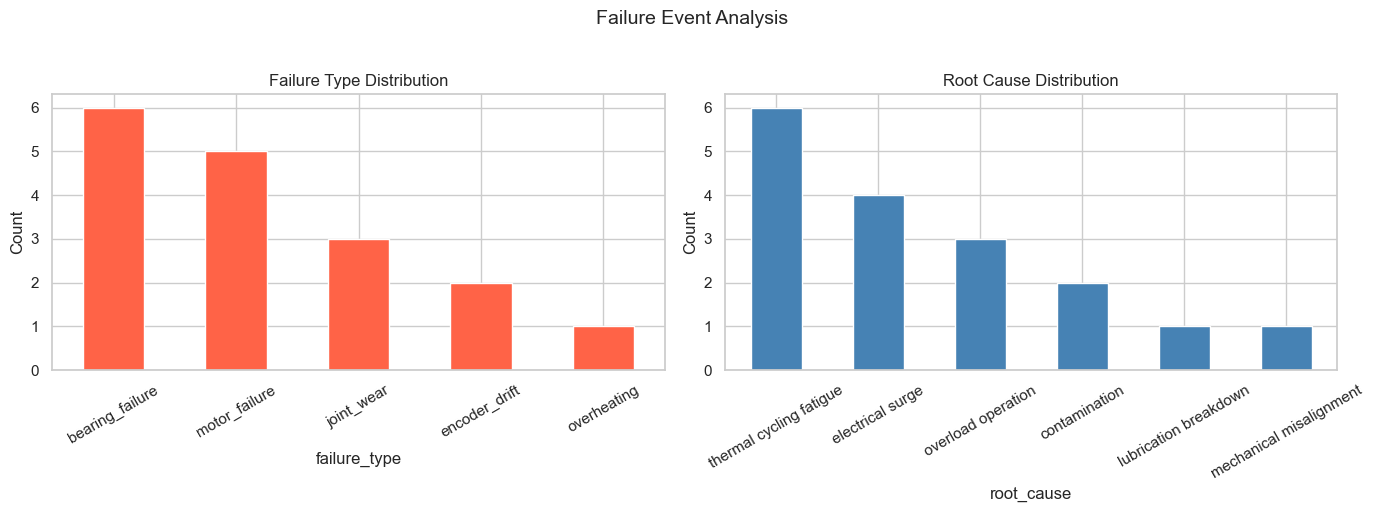

In [318]:
# Count failure types to understand which failures are most common.

failure_counts = failure_df["failure_type"].value_counts()

display(failure_counts)

# Failure Event Analysis 

# Compute total robots
total_robots = robot_df["robot_id"].nunique()

# Compute failure coverage
robots_with_failures = failure_df["robot_id"].nunique()
robots_without_failures = total_robots - robots_with_failures

print("=== Failure Coverage ===")
print(f"Total robots                 : {total_robots}")
print(f"Robots with failures         : {robots_with_failures} ({robots_with_failures / total_robots:.0%})")
print(f"Robots without failures      : {robots_without_failures} ({robots_without_failures / total_robots:.0%})")

# Multiple failures per robot
print("\n=== Multiple Failures Per Robot ===")
failure_per_robot = failure_df["robot_id"].value_counts()
print(failure_per_robot)

# Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Failure type distribution
failure_type_counts = failure_df["failure_type"].value_counts()
failure_type_counts.plot(
    kind="bar",
    ax=axes[0],
    color="tomato",
    edgecolor="white"
)
axes[0].set_title("Failure Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Root cause distribution
root_cause_counts = failure_df["root_cause"].value_counts()
root_cause_counts.plot(
    kind="bar",
    ax=axes[1],
    color="steelblue",
    edgecolor="white"
)
axes[1].set_title("Root Cause Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

# Overall title
plt.suptitle("Failure Event Analysis", fontsize=14, y=1.02)

# Layout and save
plt.tight_layout()
plt.savefig("../reports/figures/failure_analysis.png", dpi=300, bbox_inches="tight")

plt.show()

## Failure Distribution by Factory Location

factory_location
Tokyo Factory     5
Hokkaido Lab      5
Fukuoka Center    4
Osaka Plant       2
Nagoya Site       1
Name: count, dtype: int64

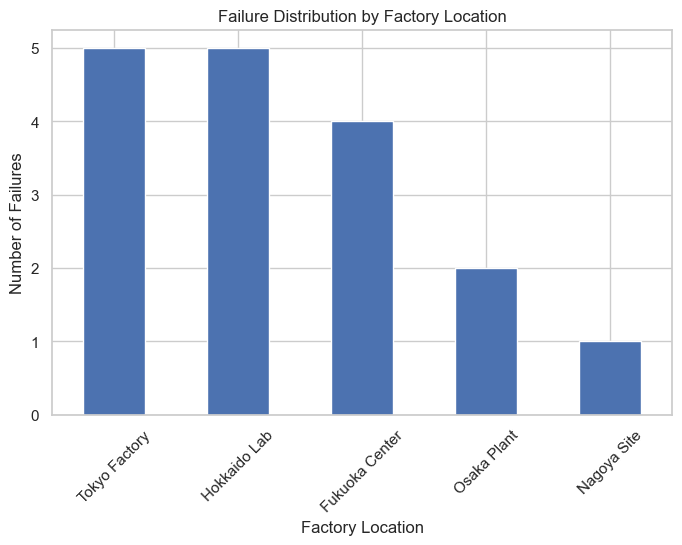

In [338]:
# Merge failure events with robot metadata to get factory location
failure_with_location = failure_df.merge(
    robot_df[["robot_id", "factory_location"]],
    on="robot_id",
    how="left"
)

# Count how many failures occurred in each factory location
location_failure_counts = failure_with_location["factory_location"].value_counts()

display(location_failure_counts)

plt.figure(figsize=(8, 5))
location_failure_counts.plot(kind="bar")
plt.title("Failure Distribution by Factory Location")
plt.xlabel("Factory Location")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45)
plt.savefig("../reports/figures/failure_distribution_by_factory_location.png", dpi=300, bbox_inches="tight")
plt.show()

## Identify failed vs functional robots

In [320]:
# Get unique robot IDs that have failed
failed_robot_ids = set(failure_df["robot_id"].unique())

# Create a copy of robot_df to avoid modifying original data
robot_status_df = robot_df.copy()

# Add a status column
robot_status_df["status"] = robot_status_df["robot_id"].apply(
    lambda x: "Failed" if x in failed_robot_ids else "Functional"
)

display(robot_status_df.head())

,robot_id,model_type,installation_date,factory_location,operating_environment,status
0,ROB-0001,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",Functional
1,ROB-0002,ARM-X9,2023-02-05,Osaka Plant,"Clean Room (20-22°C, 40% RH)",Functional
2,ROB-0003,ASSEMBLY-A3,2023-04-19,Osaka Plant,"Clean Room (20-22°C, 40% RH)",Functional
3,ROB-0004,ARM-X7,2023-02-25,Tokyo Factory,"Clean Room (20-22°C, 40% RH)",Functional
4,ROB-0005,ASSEMBLY-A3,2023-02-20,Hokkaido Lab,"Climate Controlled (22-25°C, 50% RH)",Functional


## Distribution of Robot Status by Factory

In [321]:
# Count robots by factory and status
factory_status_distribution = robot_status_df.groupby(
    ["factory_location", "status"]
).size().unstack(fill_value=0)

# Add total robots per factory
factory_status_distribution["Total"] = factory_status_distribution.sum(axis=1)

# Calculate failure rate
factory_status_distribution["Failure Rate"] = (
    factory_status_distribution["Failed"] / factory_status_distribution["Total"]
)

display(factory_status_distribution)

status,Failed,Functional,Total,Failure Rate
factory_location,,,,
Fukuoka Center,4,3,7,0.571429
Hokkaido Lab,5,10,15,0.333333
Nagoya Site,1,9,10,0.100000
Osaka Plant,2,6,8,0.250000
Tokyo Factory,5,5,10,0.500000


## Failure Rate By Factory Location

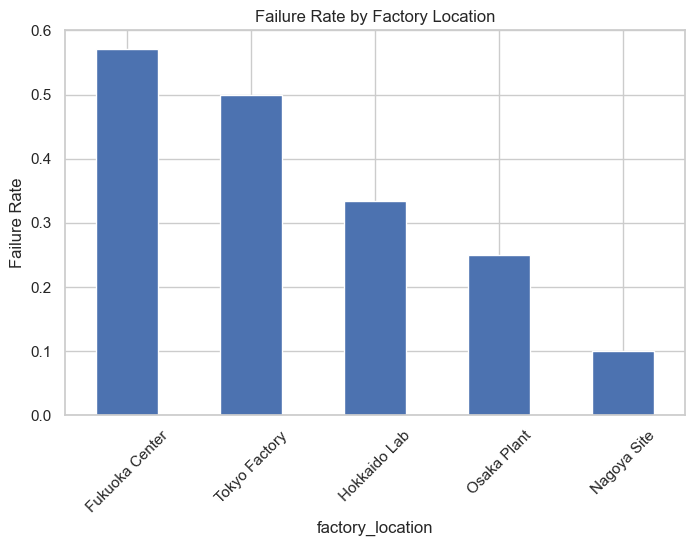

In [339]:
factory_status_distribution["Failure Rate"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Failure Rate by Factory Location")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.savefig("../reports/figures/failure_rate_by_factory_location.png", dpi=300, bbox_inches="tight")
plt.show()

### Class Imbalance

There are only 17 failure events across 50 robots.

Implication:
- RUL modelling is limited to failure robots
- risk of overfitting is high
- careful validation is required

## Robot Distribuion by Factory Location

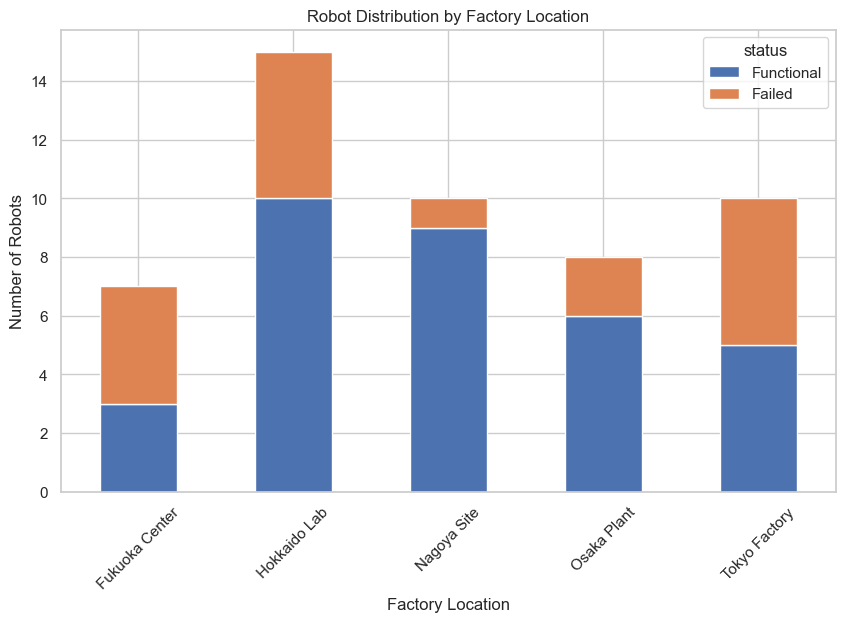

In [340]:
factory_status_distribution[["Functional", "Failed"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Robot Distribution by Factory Location")
plt.xlabel("Factory Location")
plt.ylabel("Number of Robots")
plt.xticks(rotation=45)
plt.savefig("../reports/figures/robot_distribution_by_factory_location.png",dpi=300,bbox_inches="tight")
plt.show()

### Robot Distribution and Failure Risk

This view combines:
- total number of robots (scale)
- failed vs functional robots (composition)
- failure rate (risk)

This ensures decisions are not based on raw counts alone.

For example:
A location with fewer robots but higher failure rate may require more urgent attention than a high-volume location with lower risk.

### Failure Distribution by Factory Location

This analysis shows how failures are distributed across different factory locations.

Insights from this view can help:
- identify high-risk operational environments
- detect location-specific reliability issues
- inform targeted maintenance strategies

If certain locations show higher failure counts, further investigation may be needed to understand:
- environmental conditions (temperature, humidity)
- operational intensity
- maintenance practices

Note:
The dataset contains only 17 failure events, so results should be interpreted cautiously.

## Maintenance Log Analysis

=== Maintenance Type Distribution ===
maintenance_type
calibration    86
inspection     83
lubrication    68
repair         16
replacement     9
Name: count, dtype: int64

=== Downtime Statistics (hours) ===
count    262.000000
mean       4.371756
std        8.059542
min        0.500000
25%        1.525000
50%        2.400000
75%        3.300000
max       45.800000
Name: downtime_hours, dtype: float64

=== Maintenance Events Per Robot ===
count    50.000000
mean      5.240000
std       1.021404
min       3.000000
25%       5.000000
50%       5.000000
75%       6.000000
max       7.000000
dtype: float64

=== Timestamp Availability ===
Columns available: ['maintenance_id', 'robot_id', 'maintenance_type', 'issue_detected', 'downtime_hours']
Possible timestamp columns: []
Missing robot_id values: 0


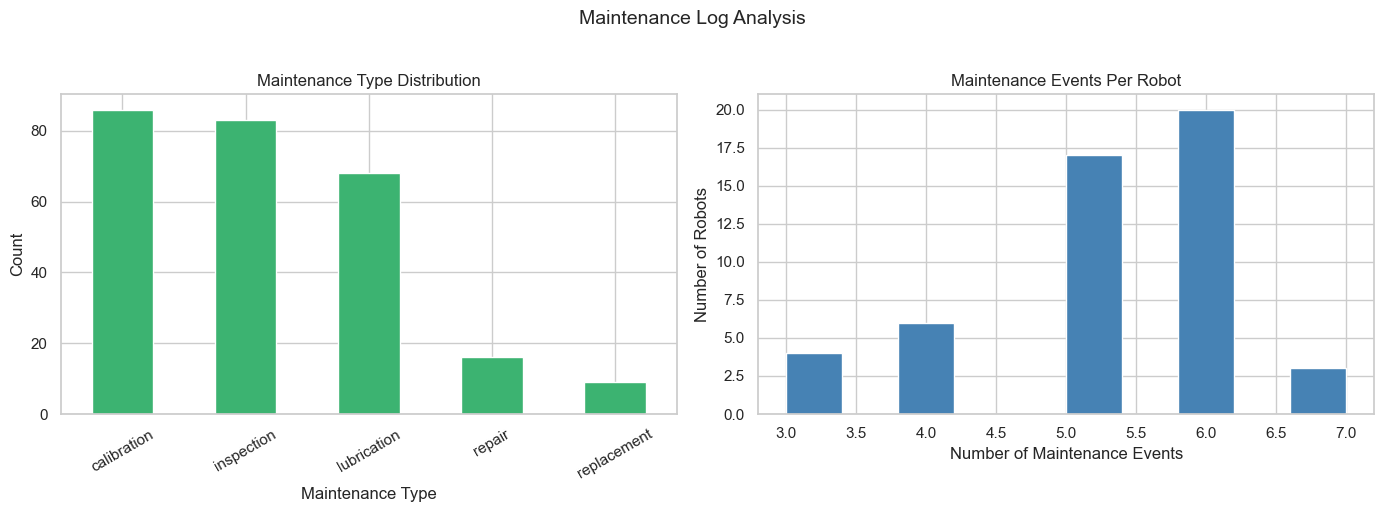

In [341]:
# Maintenance Log Analysis

# Count maintenance types
maintenance_type_counts = maintenance_df["maintenance_type"].value_counts()

print("=== Maintenance Type Distribution ===")
print(maintenance_type_counts)

# Summarise downtime
print("\n=== Downtime Statistics (hours) ===")
print(maintenance_df["downtime_hours"].describe())

# Count maintenance events per robot
maintenance_events_per_robot = maintenance_df.groupby("robot_id").size()

print("\n=== Maintenance Events Per Robot ===")
print(maintenance_events_per_robot.describe())

# Check whether maintenance logs contain a timestamp column.
# Time since last maintenance can only be calculated if a maintenance date or timestamp exists.
possible_time_columns = [
    col for col in maintenance_df.columns
    if "date" in col.lower() or "timestamp" in col.lower()
]

print("\n=== Timestamp Availability ===")
print("Columns available:", maintenance_df.columns.tolist())
print("Possible timestamp columns:", possible_time_columns)
print("Missing robot_id values:", maintenance_df["robot_id"].isnull().sum())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Maintenance type distribution
maintenance_type_counts.plot(
    kind="bar",
    ax=axes[0],
    color="mediumseagreen",
    edgecolor="white"
)

axes[0].set_title("Maintenance Type Distribution")
axes[0].set_xlabel("Maintenance Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Maintenance events per robot
maintenance_events_per_robot.plot(
    kind="hist",
    ax=axes[1],
    bins=10,
    color="steelblue",
    edgecolor="white"
)

axes[1].set_title("Maintenance Events Per Robot")
axes[1].set_xlabel("Number of Maintenance Events")
axes[1].set_ylabel("Number of Robots")

plt.suptitle("Maintenance Log Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/maintenance_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### Stakeholder Interpretation

This section examines maintenance activity across the robot fleet.

We review:
- maintenance type distribution
- downtime severity
- maintenance events per robot
- whether maintenance timestamps are available

This helps determine how maintenance data can be used later in feature engineering.

Important limitation:
The maintenance log does not contain a maintenance timestamp. This means we cannot compute time-based features such as "time since last maintenance".

However, the data can still support aggregate features such as:
- total maintenance events per robot
- average downtime per robot
- repair vs inspection counts
- total downtime per robot

## Summary Statistics of Overall Sensor

In [325]:
# Generate overall summary statistics for the sensor dataframe.
# This helps us understand overall data distribution, typical ranges,
# and detect potential outliers across the dataset.

sensor_df.describe()

,timestamp,vibration_level,motor_temperature,torque_load,power_consumption
count,76730,76730.000000,76730.000000,76730.000000,76730.000000
mean,2023-10-20 00:04:49.388765952,0.345431,57.098948,105.013390,1296.795790
min,2023-01-07 00:00:00,0.050000,34.800000,38.600000,449.100000
25%,2023-06-29 12:00:00,0.243000,49.500000,79.700000,919.900000
50%,2023-10-13 18:00:00,0.345000,57.100000,105.000000,1296.650000
75%,2024-02-12 06:00:00,0.447000,64.600000,130.200000,1672.275000
max,2024-06-30 00:00:00,0.771000,89.800000,183.000000,2303.100000
std,NaN,0.127222,9.097891,29.635359,436.006783


### Summary Statistics of Overall Sensor 

The dataset contains approximately 18 months of sensor readings across multiple robots.

Key observations:

- Vibration values range from 0.05 to 0.77, showing moderate variability.
- Temperature ranges between 34.8°C and 89.8°C, indicating diverse operating conditions.
- Torque shows high variability, suggesting fluctuating mechanical load.
- Power consumption has the widest range, indicating significant variation in energy usage.

Feature scaling will be required before modelling, as sensors operate on different numerical ranges.

Modelling implication:
Sensors such as torque and power consumption may provide stronger predictive signals due to higher variability, while vibration may capture more subtle degradation patterns.


## Sensor Reading Distribution

Sensor Descriptive Statistics
       vibration_level  motor_temperature   torque_load  power_consumption
count     76730.000000       76730.000000  76730.000000       76730.000000
mean          0.345431          57.098948    105.013390        1296.795790
std           0.127222           9.097891     29.635359         436.006783
min           0.050000          34.800000     38.600000         449.100000
25%           0.243000          49.500000     79.700000         919.900000
50%           0.345000          57.100000    105.000000        1296.650000
75%           0.447000          64.600000    130.200000        1672.275000
max           0.771000          89.800000    183.000000        2303.100000


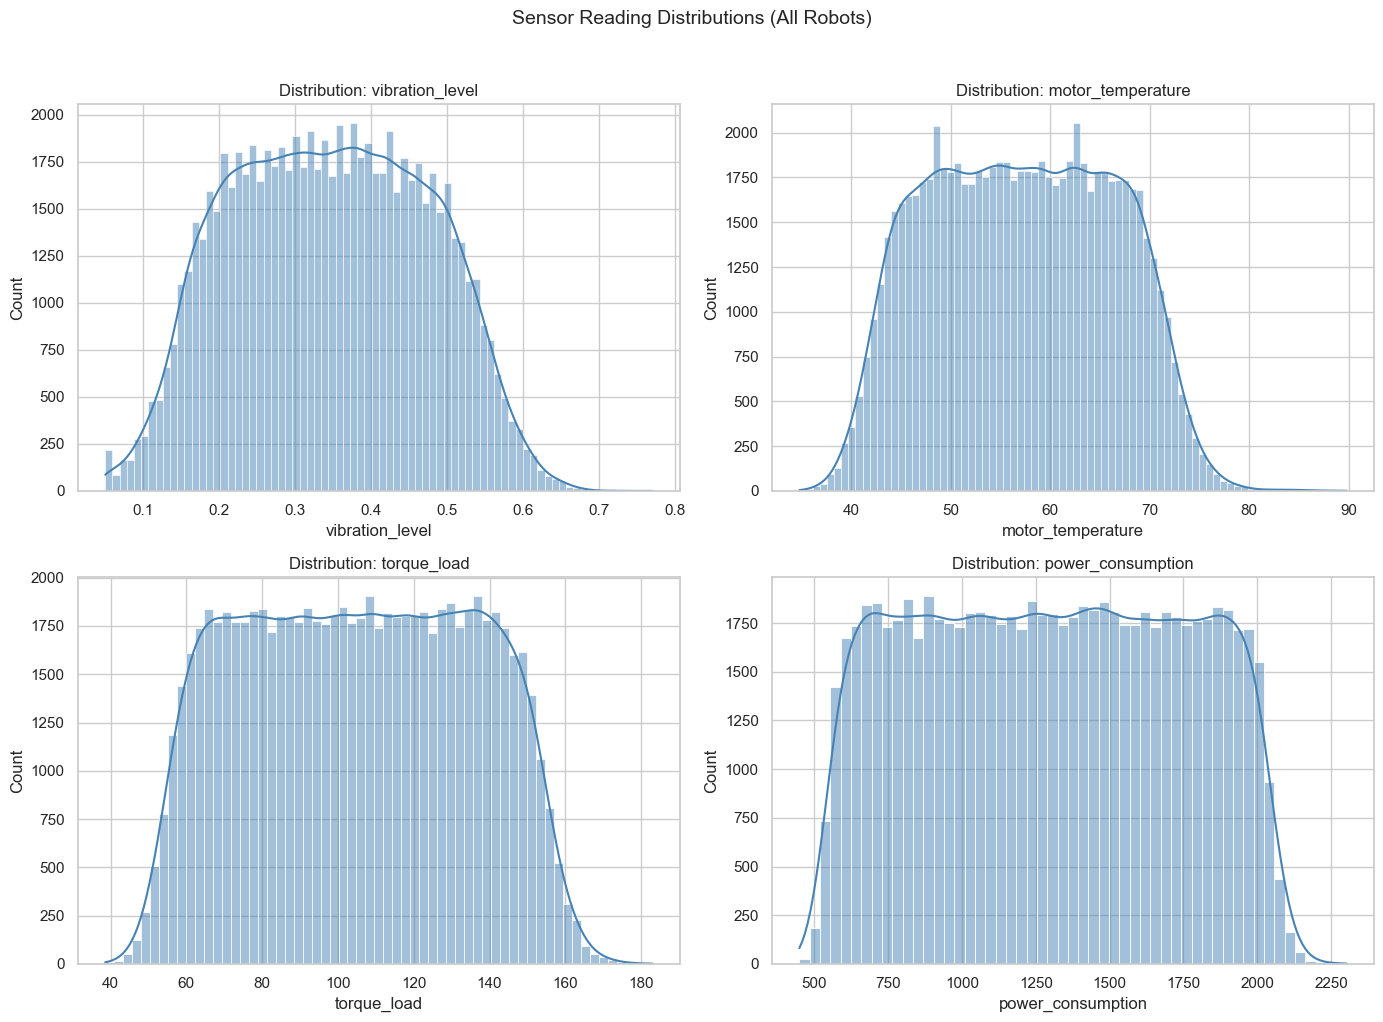

In [342]:
# Sensor Distribution

sensor_columns = ['vibration_level', 'motor_temperature',
               'torque_load', 'power_consumption']

print("Sensor Descriptive Statistics")
print(sensor_df[sensor_columns].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), sensor_columns):
    sns.histplot(sensor_df[col], ax=ax, kde=True,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel(col)

plt.suptitle('Sensor Reading Distributions (All Robots)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Stakeholder Interpretation

Sensor reading distributions help us understand normal operating behaviour.

Unusual spikes may represent:
- actual degradation
- extreme operating conditions
- sensor noise
- data quality issues

This will guide cleaning and feature engineering decisions.

## Outlier Detection

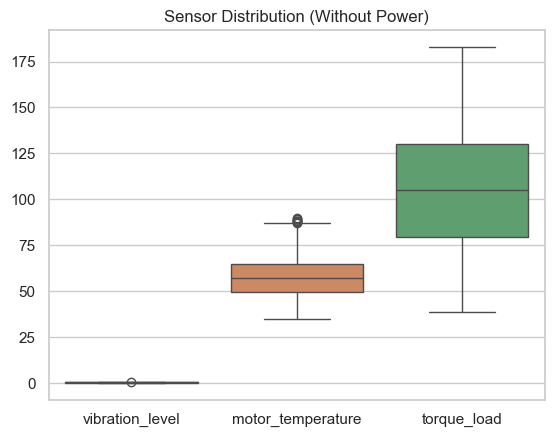

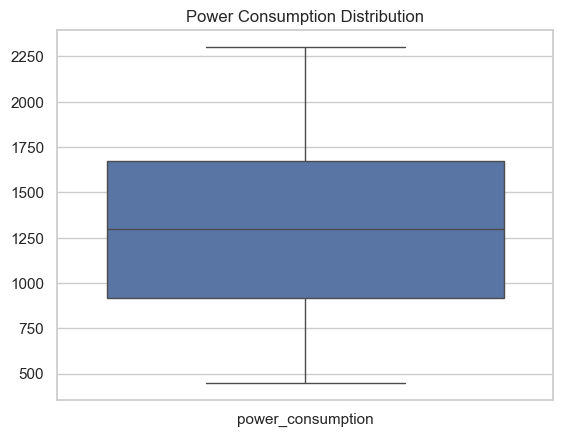

In [327]:
sns.boxplot(data=sensor_df[
    ["vibration_level", "motor_temperature", "torque_load"]
])
plt.title("Sensor Distribution (Without Power)")
plt.savefig("../reports/figures/sensor_boxplots_without_power.png", dpi=300, bbox_inches="tight")
plt.show()

sns.boxplot(data=sensor_df[["power_consumption"]])
plt.title("Power Consumption Distribution")
plt.savefig("../reports/figures/power_consumption_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Sensor Distribution Interpretation

The boxplots show how sensor values vary across all robots.

### Key Insights

- **Vibration** shows low variability, capturing subtle mechanical changes.  
- **Temperature** has moderate spread, reflecting varying operating conditions.  
- **Torque** shows high variability, indicating fluctuating mechanical load.  
- **Power consumption** has the widest range and is plotted separately due to its larger scale.

### Business Meaning

Higher variability, especially in torque and power, may indicate system stress or instability before failure.

### Modelling Implication

- Feature scaling is required due to different sensor ranges.  
- Variability-based features will likely be more useful than raw values for prediction.

## Sensor Volatility Analysis Per Robot

In [328]:
sensor_df.groupby("robot_id")[
    ["vibration_level", "motor_temperature", "torque_load", "power_consumption"]
].std().describe()

,vibration_level,motor_temperature,torque_load,power_consumption
count,50.000000,50.000000,50.000000,50.000000
mean,0.125777,8.977803,29.697839,436.154520
std,0.002665,0.252796,0.712103,5.518003
min,0.117697,8.683659,28.527116,425.453187
25%,0.124447,8.822789,29.221801,432.364003
50%,0.125957,8.919120,29.460484,436.013019
75%,0.127086,9.025156,30.070481,439.565720
max,0.131693,10.230631,31.481348,448.995207


## Sensor Volatility Analysis Per Robot

This analysis measures how much sensor readings fluctuate within each robot over time.

### Key Insights

- **Torque and power consumption show the highest variability**, indicating changing workload and operational stress.
- **Vibration and temperature are more stable**, but still show meaningful fluctuations.

### Interpretation

Higher variability suggests instability, which may be linked to degradation or failure behaviour.

### Modelling Implication

- Variability is a key signal for predictive maintenance.  
- Features such as rolling standard deviation and rate of change will be important for modelling.

## General Sensor Correlation

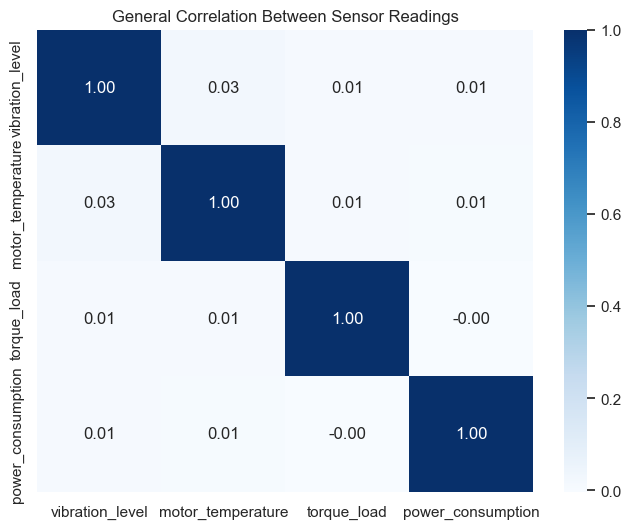


Average Sensor Levels: Failed vs Non-Failed Robots


,vibration_level,motor_temperature,torque_load,power_consumption
No Failure (33 robots),0.341,56.761,104.256,1293.121
Confirmed Failure (17 robots),0.363,58.463,108.068,1311.616


In [343]:
# ─── General Sensor Correlation ────────────────────────────────────────────

sensor_columns = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption"
]

correlation_matrix = sensor_df[sensor_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("General Correlation Between Sensor Readings")
plt.savefig("../reports/figures/general_sensor_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

# Failed vs Non-Failed Sensor Comparison

failed_robot_ids = failure_df["robot_id"].unique()

sensor_status_df = sensor_df.copy()
sensor_status_df["failure_flag"] = sensor_status_df["robot_id"].isin(failed_robot_ids)

failed_robot_count = failure_df["robot_id"].nunique()
total_robot_count = sensor_df["robot_id"].nunique()
non_failed_robot_count = total_robot_count - failed_robot_count

comparison = sensor_status_df.groupby("failure_flag")[sensor_columns].mean()

comparison.index = [
    f"No Failure ({non_failed_robot_count} robots)",
    f"Confirmed Failure ({failed_robot_count} robots)"
]

print("\nAverage Sensor Levels: Failed vs Non-Failed Robots")
display(comparison.round(3))

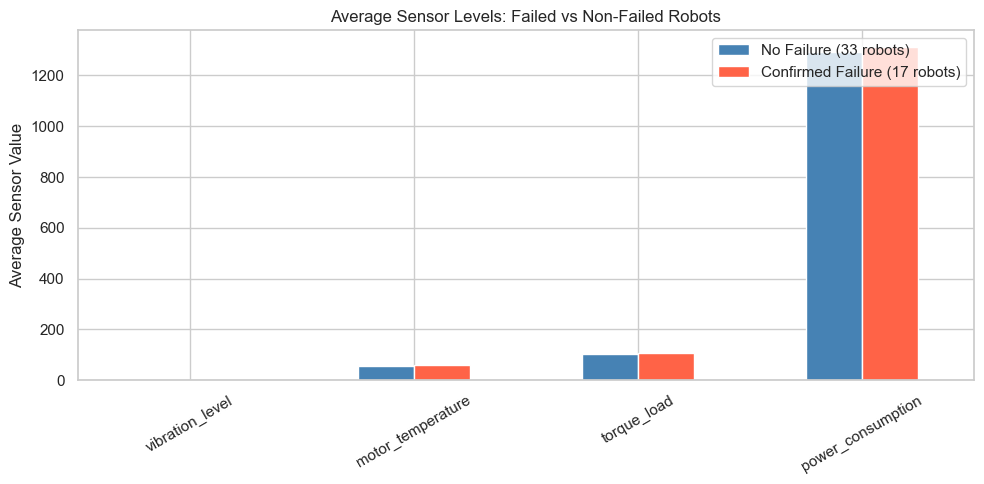

In [345]:
comparison.T.plot(kind="bar", figsize=(10, 5), color=["steelblue", "tomato"],
                  edgecolor="white")
plt.title("Average Sensor Levels: Failed vs Non-Failed Robots")
plt.ylabel("Average Sensor Value")
plt.xticks(rotation=30)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../reports/figures/failed_vs_nonfailed_sensors.png",
            dpi=300, bbox_inches="tight")
plt.show()

## General Sensor Correlation

This heatmap shows the relationship between sensor readings across all robots.

### Key Insights

- Correlation values are very close to zero across all sensor pairs.
- This indicates that sensors behave largely **independently** of one another.
- There is no strong linear relationship between vibration, temperature, torque, and power.

### Interpretation

Each sensor captures a **different aspect of the robot’s behaviour**, rather than overlapping signals.

### Modelling Implication

- Combining multiple sensors is important, as each contributes unique information.
- There is low risk of redundancy from correlated features.
- Models will benefit from learning interactions between independent signals rather than relying on single dominant relationships.

## Failed-Robot Sensor Correlation

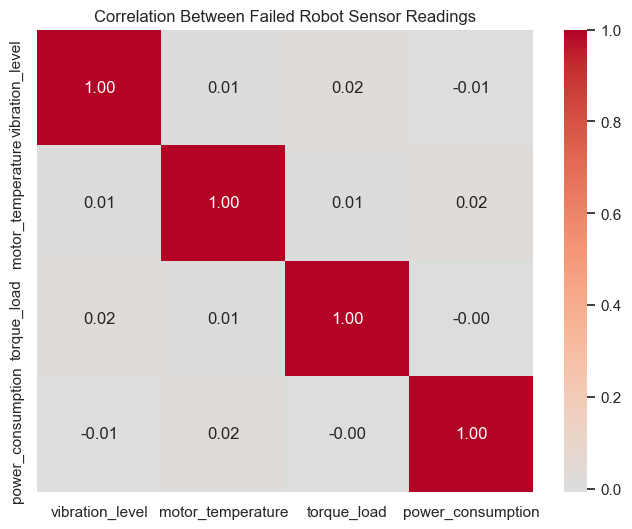

In [330]:
# Failed-Robot Sensor Correlation

failed_sensor = sensor_status_df[
    sensor_status_df["failure_flag"] == True
].copy()

failed_correlation_matrix = failed_sensor[sensor_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    failed_correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Failed Robot Sensor Readings")
plt.savefig("../reports/figures/failed_robot_sensor_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## Failed-Robot Sensor Correlation

This heatmap focuses only on robots that experienced failure.

### Key Insights

- Correlation values remain very low, even near failure conditions.
- No strong relationships emerge between sensor variables prior to failure.
- Sensor behaviour does not become more linearly related as failure approaches.

### Interpretation

Failure does not appear to be driven by a simple relationship between sensors.
Instead, it is likely influenced by **complex patterns and instability within individual signals**.

### Modelling Implication

- Predictive models should not rely on linear relationships between sensors.
- Feature engineering should focus on:
  - trends over time
  - volatility and fluctuations
  - changes in behaviour rather than absolute values
- Non-linear models (e.g. tree-based models) will be more suitable than simple linear models.

In [331]:
# Count failure types to understand which failures are most common.
failure_df["failure_type"].value_counts()

failure_type
bearing_failure    6
motor_failure      5
joint_wear         3
encoder_drift      2
overheating        1
Name: count, dtype: int64

In [332]:
# We use this as an initial case study to check whether sensor behaviour changes before failure.

# Choose failure type to filter by
selected_failure_type = "bearing_failure"  # We can change this to any failure type present in the dataset

# Filter failures by the selected failure type
filtered_failures = failure_df[
    failure_df["failure_type"] == selected_failure_type
]

# Select one robot from the filtered failures
sample_failure_record = filtered_failures.iloc[0]

sample_failed_robot = sample_failure_record["robot_id"]
sample_failure_time = sample_failure_record["failure_time"]
sample_failure_type = sample_failure_record["failure_type"]

# Get the sensor data for the selected robot
sample_robot_data = sensor_df[
    sensor_df["robot_id"] == sample_failed_robot
].sort_values("timestamp").copy()

# Print info
print("Sample failed robot:", sample_failed_robot)
print("Failure type:", sample_failure_type)
print("Failure time:", sample_failure_time)

Sample failed robot: ROB-0018
Failure type: bearing_failure
Failure time: 2024-04-06 00:00:00


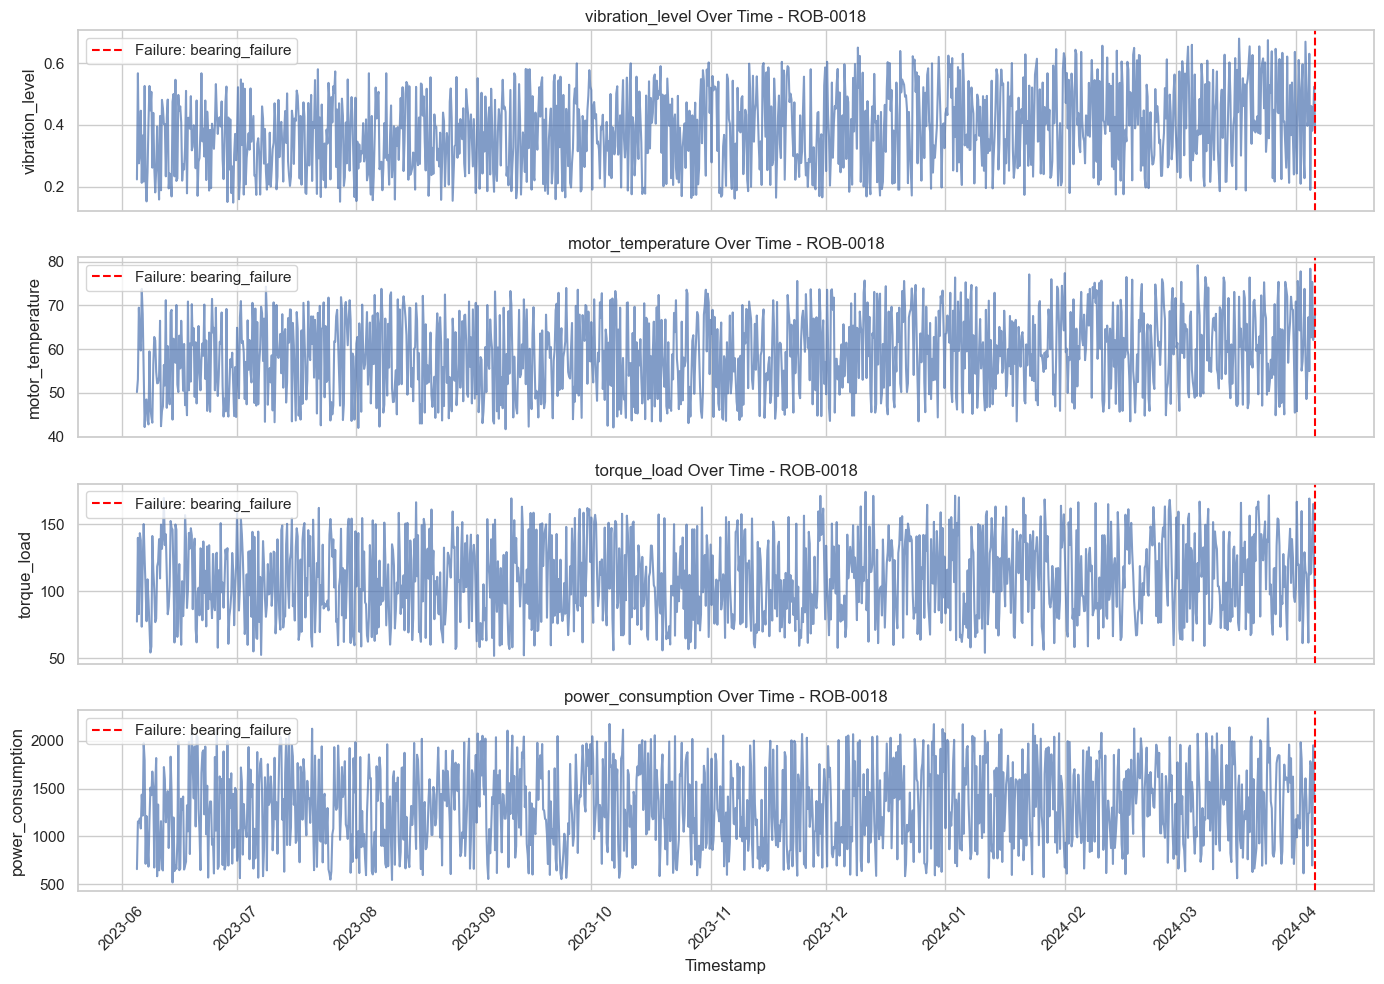

In [344]:
# Define the sensor columns you want to visualize
sensor_columns = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption"
]

# Keep only columns that actually exist in the dataset
available_sensor_columns = [
    col for col in sensor_columns
    if col in sample_robot_data.columns
]

# Create one plot per sensor
fig, axes = plt.subplots(
    nrows=len(available_sensor_columns),
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

for ax, sensor in zip(axes, available_sensor_columns):
    ax.plot(
        sample_robot_data["timestamp"],
        sample_robot_data[sensor],
        alpha=0.7
    )
    
    ax.axvline(
        sample_failure_time,
        color="red",
        linestyle="--",
        label=f"Failure: {sample_failure_type}"
    )
    
    ax.set_title(f"{sensor} Over Time - {sample_failed_robot}")
    ax.set_ylabel(sensor)
    ax.legend()

plt.xlabel("Timestamp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/bearing_failure_sensor_trends.png", dpi=300, bbox_inches="tight")
plt.show()

## Failure-Type Case Study: Bearing Failure

This analysis shows sensor behaviour over time for a robot that experienced a **bearing failure**.

The red dashed line marks the point of failure.

### Key Insights

- Sensor readings (vibration, temperature, torque, and power) show noticeable **fluctuations** leading up to failure.  
- There is no single smooth upward trend, but rather **increasing instability** across multiple sensors.  
- Vibration and torque appear particularly variable, which may reflect mechanical wear associated with bearing issues.

### Interpretation

Failure does not occur as a simple linear increase in sensor values.  
Instead, it is preceded by **irregular behaviour and volatility**, suggesting degradation in system stability.

### Modelling Implication

- Predictive models should focus on **patterns over time**, not just raw sensor values.  
- Features such as rolling averages, rolling standard deviation, and rate of change will be important.  
- Failure-type-specific patterns may exist, but should be validated across multiple robots before drawing strong conclusions.

## Sensor behaviour before failure across robots

In [334]:
# Filter only failed robots and their sensor readings for time-to-failure analysis
failed_robot_ids = failure_df["robot_id"].unique()

failed_sensor = sensor_df[
    sensor_df["robot_id"].isin(failed_robot_ids)
].copy()

# Attach failure time to sensor readings for failed robots
failed_sensor = failed_sensor.merge(
    failure_df[["robot_id", "failure_time"]],
    on="robot_id",
    how="left"
)

# Calculate time to failure for each sensor reading (in hours)
failed_sensor["time_to_failure"] = (
    failed_sensor["failure_time"] - failed_sensor["timestamp"]
    ).dt.total_seconds() / 3600

# Keep only sensor readings that occurred before failure (time_to_failure >= 0)
failed_sensor = failed_sensor[
    failed_sensor["time_to_failure"] >= 0
].copy()

# Filter to a reasonable window before failure (e.g., 200 hours) for analysis
window_data = failed_sensor[
    failed_sensor["time_to_failure"] <= 200
].copy()

# Create time bins for easier analysis (e.g., 0-5 hours, 5-10 hours, etc.)
window_data["time_bin"] = (window_data["time_to_failure"] // 5) * 5

# Aggregate across robots to get average sensor readings in each time bin before failure
agg = window_data.groupby("time_bin")[
    ["vibration_level", "motor_temperature", "torque_load", "power_consumption"]
].mean().reset_index()

# Sort for correct plotting order
agg = agg.sort_values("time_bin")

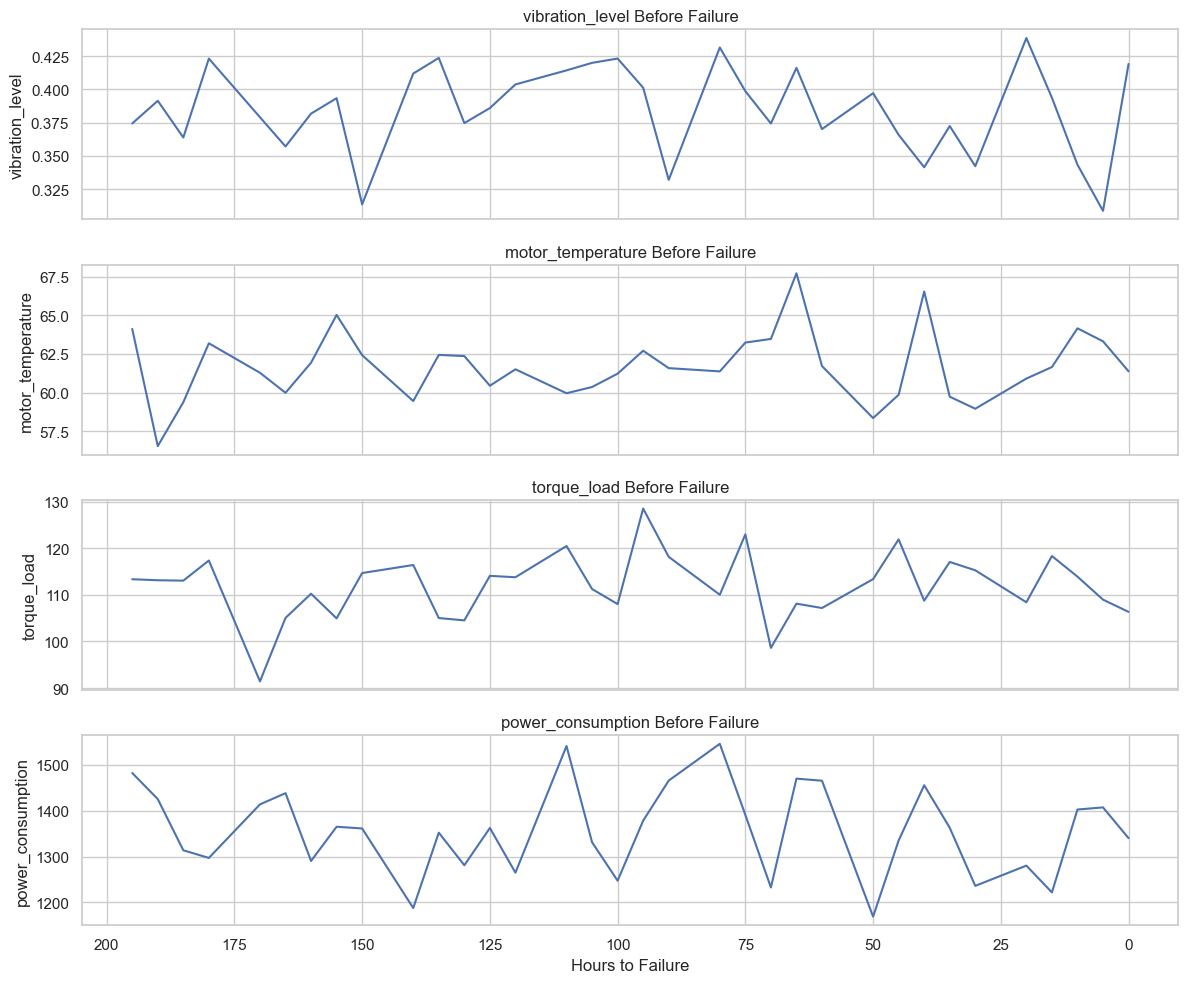

In [335]:
# Plot sensor trends leading up to failure for vibration, temperature, and torque. 
# We invert the x-axis to show time moving towards failure on the right.

# Define sensors
sensors = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption"
]

# Create subplots
fig, axes = plt.subplots(
    nrows=len(sensors),
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

# Plot each sensor
for ax, sensor in zip(axes, sensors):
    ax.plot(agg["time_bin"], agg[sensor])
    ax.invert_xaxis()

    ax.set_title(f"{sensor} Before Failure")
    ax.set_ylabel(sensor)

# Common x-axis label
plt.xlabel("Hours to Failure")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("../reports/figures/sensor_trends_before_failure.png", dpi=300, bbox_inches="tight")
plt.show()



### Sensor Behaviour Before Failure Across Robots

This analysis aligns sensor readings from all failed robots relative to their failure time.

Instead of using calendar time, we transform each reading into **hours before failure**, allowing us to compare patterns across different robots.

The x-axis is inverted so that:
- left = far from failure  
- right = close to failure  

### Key Insights

- Sensor trends are **not smooth or linear** as failure approaches.  
- All sensors show noticeable **fluctuations and instability** before failure.  
- No single sensor consistently increases toward failure across all robots.  

### Interpretation

Failure is not driven by a simple rise in sensor values.  
Instead, it appears to be preceded by **unstable and irregular behaviour** across multiple sensors.

### Modelling Implication

- Raw sensor values alone are unlikely to be sufficient for prediction.  
- Feature engineering should focus on:
  - rolling averages  
  - rolling standard deviation  
  - rate of change  
  - volatility patterns  

- Models that capture **non-linear patterns** (e.g. tree-based models) will be more suitable.

### Business Insight

Predictive maintenance should monitor **changes in behaviour**, not just high sensor values.  
Early warning signals are more likely to come from instability rather than absolute thresholds.

## EDA Decisions for Phase 2

Based on the findings:

- RUL labels will only be created for failed robots.
- Non-failed robots will be treated as censored.
- Maintenance features will be aggregate only because no maintenance timestamp exists.
- Rolling and volatility features will be prioritized in feature engineering.
- Robot-level splitting will be required to avoid leakage.

## EDA Summary and Key Findings

### What the data tells us

| Finding | Business Implication |
|---|---|
| 17 of 50 robots have confirmed failures (~34%) | RUL labels can only be computed for a limited portion of the fleet |
| 33 robots have no failure record | These are censored robots and will not be assigned artificial RUL labels |
| Sensor readings appear to follow a consistent 6-hour interval. | Rolling window features will be structurally reliable |
| Failed robots show marginally higher vibration and temperature | A degradation signal exists but is weak and not easily separable |
| No missing values in any table | No imputation required at this stage |
| Each robot appears to have a single recorded failure event | No evidence of recurring failure patterns within this dataset |
| Bearing failure is the most common failure type | Mechanical wear is the primary operational risk |
| Thermal cycling fatigue is the leading root cause | Temperature management is critical for fleet reliability |
| Maintenance table has no timestamp column | Time-based maintenance features cannot be constructed |
| Failure is preceded by instability rather than smooth trends | Feature engineering must capture volatility and behavioural changes |

---

### Modelling Strategy Implications

- Two modelling tracks will be used:
  - RUL regression (failed robots only)
  - Health classification (entire fleet)

- Predictive performance will depend heavily on:
  - rolling statistics
  - volatility features
  - time-based behavioural patterns

- Non-linear models are expected to perform better than linear models

---

### Assumptions

- Robots without failure events are treated as censored observations, not confirmed healthy systems  
- RUL will only be computed using confirmed failure timestamps  
- Maintenance features will be limited to aggregate metrics (e.g. counts, total downtime)  
- Health classification thresholds will be defined with business input in Phase 2  

---

### Risks

- Small failure sample (17 robots) limits regression model reliability  
- Censored robots introduce uncertainty into classification boundaries  
- Sensor differences between failed and non-failed robots are subtle, requiring strong feature engineering  
- Lack of maintenance timestamps removes an entire class of time-based degradation signals  

---

*Prepared for technical and non-technical stakeholder review.  
All findings are grounded in observed data without introducing unsupported assumptions.*